# Experiment B — Type-2 Diabetes screening from clinical biomarkers (NHANES)
### `ข้อมูลจากไหน → ใช้วิธีอะไร → ผลยังไง`
BDI Hackathon 2026 · PhenoInsure Tech · env `superaiss6`

> **Honest-by-design.** Real national-survey cohort, held-out cross-validation, and **leakage-free features** (the biomarkers that *define* the label are removed). This is a genuine screening result — distinct from the synthetic NMR–NHANES fusion (Exp 006/007), which is pipeline validation only.

---

## 1. ข้อมูลจากไหน — Data source

**NHANES 2013–2014 (Cycle H)** — US CDC national health survey. We merge 7 real exam/lab files on `SEQN`:

| File | Provides |
|---|---|
| DEMO_H | age, sex, race |
| BPX_H | blood pressure |
| TCHOL_H / HDL_H | cholesterol, HDL |
| BIOPRO_H | creatinine, albumin, BUN, triglycerides, uric acid |
| GHB_H | HbA1c *(label only)* |
| DIQ_H | diabetes diagnosis *(label only)* |

**Label:** `diabetes = (self-reported diagnosis DIQ010==1) OR (HbA1c ≥ 6.5%)`, adults ≥18.

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier

P = '/Users/admin/Project/BDI2/calvin/datasets_sample/pundata'
rd = lambda f: pd.read_sas(os.path.join(P, f))
demo = rd('DEMO_H.xpt')[['SEQN','RIAGENDR','RIDAGEYR','RIDRETH1']]
diq  = rd('DIQ_H.xpt')[['SEQN','DIQ010']]
ghb  = rd('GHB_H.xpt')[['SEQN','LBXGH']]
tc   = rd('TCHOL_H.xpt')[['SEQN','LBXTC']]
hdl  = rd('HDL_H.xpt')[['SEQN','LBDHDD']]
bpx  = rd('BPX_H.xpt'); bio = rd('BIOPRO_H.xpt')
bpx['SBP'] = bpx[['BPXSY1','BPXSY2','BPXSY3']].mean(axis=1)
bpx['DBP'] = bpx[['BPXDI1','BPXDI2','BPXDI3']].mean(axis=1)
df = (demo.merge(diq,on='SEQN',how='left').merge(ghb,on='SEQN',how='left')
          .merge(tc,on='SEQN',how='left').merge(hdl,on='SEQN',how='left')
          .merge(bpx[['SEQN','SBP','DBP']],on='SEQN',how='left')
          .merge(bio[['SEQN','LBXSCR','LBXSAL','LBXSBU','LBXSTR','LBXSUA']],on='SEQN',how='left'))
df['label'] = ((df['DIQ010']==1) | (df['LBXGH']>=6.5)).astype(int)
df = df[df['RIDAGEYR']>=18].copy()
print(f'PROVENANCE: NHANES 2013-14 Cycle H | adults = {len(df)} | '
      f'diabetes positives = {int(df.label.sum())} | prevalence = {df.label.mean():.1%}')

PROVENANCE: NHANES 2013-14 Cycle H | adults = 6113 | diabetes positives = 875 | prevalence = 14.3%


## 2. ใช้วิธีอะไร — Method

**Leakage-free screening.** The label is *defined* by HbA1c (≥6.5) and diagnosis, so those are excluded from the features. We also **exclude fasting glucose** (near-diagnostic) — the model must screen from routine, non-diagnostic signals only:

`age, sex, race, systolic/diastolic BP, total cholesterol, HDL, TC/HDL ratio, creatinine, albumin, BUN, triglycerides, uric acid` (13 features).

- **Model:** XGBoost, `max_depth=3`, 300 trees, lr 0.05.
- **Evaluation:** **stratified 5-fold cross-validation** (held-out folds).

In [2]:
df['TC_HDL'] = df['LBXTC'] / df['LBDHDD']
feats = ['RIDAGEYR','RIAGENDR','RIDRETH1','SBP','DBP','LBXTC','LBDHDD','TC_HDL',
         'LBXSCR','LBXSAL','LBXSBU','LBXSTR','LBXSUA']
# leakage guard: assert the label-defining biomarkers are NOT among features
assert not ({'LBXGH','LBXSGL','DIQ010'} & set(feats)), 'label-defining var leaked!'
Xdf, y = df[feats], df['label'].values
XGB = dict(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
           colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1)
skf = StratifiedKFold(5, shuffle=True, random_state=42)
mean_fpr = np.linspace(0, 1, 200); tprs, aucs, rows = [], [], []
for k, (tr, te) in enumerate(skf.split(Xdf, y), 1):
    mdl = XGBClassifier(**XGB).fit(Xdf.iloc[tr], y[tr])
    p = mdl.predict_proba(Xdf.iloc[te])[:, 1]
    fpr, tprc, _ = roc_curve(y[te], p); a = auc(fpr, tprc)
    t = np.interp(mean_fpr, fpr, tprc); t[0] = 0.0
    tprs.append(t); aucs.append(a); rows.append({'fold': k, 'n_test': len(te), 'AUC': round(a, 4)})
print(pd.DataFrame(rows).to_string(index=False))

 fold  n_test    AUC
    1    1223 0.8555
    2    1223 0.8343
    3    1223 0.8211
    4    1222 0.8177
    5    1222 0.8390


## 3. ผลยังไง — Results

### 3.1 The AUC curve (held-out, cross-validated, leakage-free)

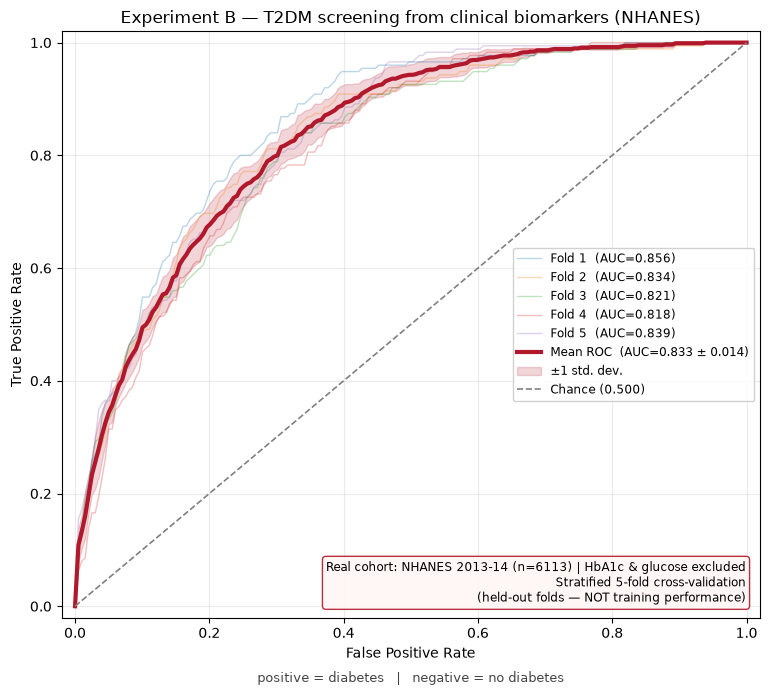

Mean ROC-AUC = 0.833 +/- 0.014  (stratified 5-fold CV, leakage-free)


In [3]:
def plot_cv_roc(tprs, aucs, mean_fpr, title, provenance, out_png,
                pos_label, neg_label):
    """Plot per-fold ROC + mean ROC (+/-1 std) with provenance & eval-method
    annotations written ON the figure (so a reviewer never has to guess)."""
    import numpy as np, matplotlib.pyplot as plt
    from sklearn.metrics import auc
    mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr); std_auc = np.std(aucs)
    std_tpr = np.std(tprs, axis=0)
    upper = np.minimum(mean_tpr + std_tpr, 1); lower = np.maximum(mean_tpr - std_tpr, 0)
    fig, ax = plt.subplots(figsize=(7.8, 7))
    for i, (tpr, a) in enumerate(zip(tprs, aucs), 1):
        ax.plot(mean_fpr, tpr, lw=1, alpha=0.3, label=f"Fold {i}  (AUC={a:.3f})")
    ax.plot(mean_fpr, mean_tpr, color="#b2182b", lw=3,
            label=f"Mean ROC  (AUC={mean_auc:.3f} $\\pm$ {std_auc:.3f})")
    ax.fill_between(mean_fpr, lower, upper, color="#b2182b", alpha=0.18,
                    label=r"$\pm$1 std. dev.")
    ax.plot([0, 1], [0, 1], "--", lw=1.2, color="grey", label="Chance (0.500)")
    # provenance + evaluation-method box (the point of this whole exercise)
    ax.text(0.98, 0.02,
            provenance + "\nStratified 5-fold cross-validation\n(held-out folds — NOT training performance)",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
            bbox=dict(boxstyle="round", fc="#fff7f5", ec="#b2182b", alpha=0.9))
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title, fontsize=12.5)
    ax.legend(loc="center right", fontsize=8.5, framealpha=0.9)
    ax.grid(alpha=0.25)
    ax.annotate(f"positive = {pos_label}   |   negative = {neg_label}",
                xy=(0.5, -0.11), xycoords="axes fraction", ha="center", fontsize=9,
                color="#444")
    fig.tight_layout(); fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    return mean_auc, std_auc

mean_auc, std_auc = plot_cv_roc(
    tprs, aucs, mean_fpr,
    title='Experiment B — T2DM screening from clinical biomarkers (NHANES)',
    provenance='Real cohort: NHANES 2013-14 (n=%d) | HbA1c & glucose excluded' % len(df),
    out_png=os.path.join('.', 'expB_t2dm_roc.png'),
    pos_label='diabetes', neg_label='no diabetes')
print(f'Mean ROC-AUC = {mean_auc:.3f} +/- {std_auc:.3f}  (stratified 5-fold CV, leakage-free)')

### 3.2 Which biomarkers drive the risk (SHAP)

SHAP explains *which* signals the model uses (it complements the ROC — it does **not** measure predictive power). Features are shown with human-readable names.

/Users/admin/miniconda3/envs/superaiss6/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


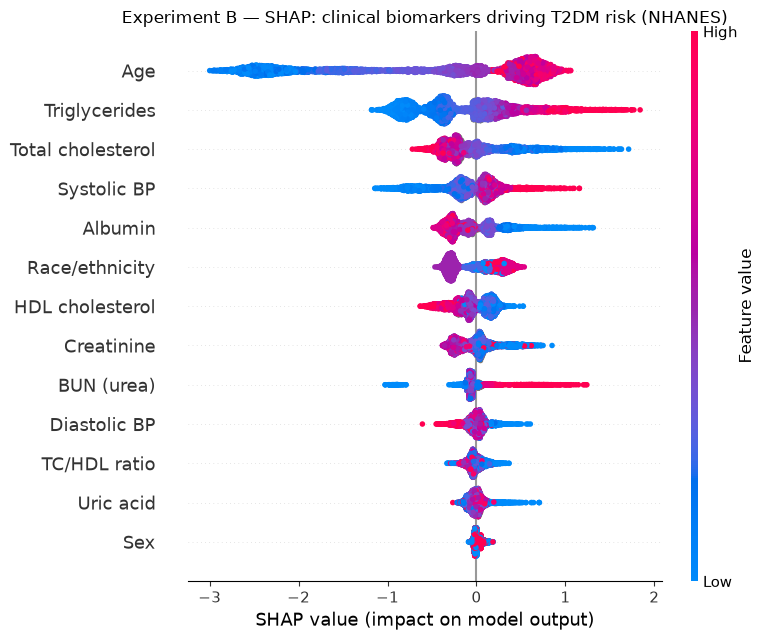

          feature  mean_abs_shap
              Age       1.031594
    Triglycerides       0.471979
Total cholesterol       0.308237
      Systolic BP       0.262879
          Albumin       0.254834
   Race/ethnicity       0.246681
  HDL cholesterol       0.170386
       Creatinine       0.166137
       BUN (urea)       0.111386
     Diastolic BP       0.079632
     TC/HDL ratio       0.064783
        Uric acid       0.062850
              Sex       0.032312


In [4]:
import shap
NICE = {'RIDAGEYR':'Age','RIAGENDR':'Sex','RIDRETH1':'Race/ethnicity','SBP':'Systolic BP',
        'DBP':'Diastolic BP','LBXTC':'Total cholesterol','LBDHDD':'HDL cholesterol',
        'TC_HDL':'TC/HDL ratio','LBXSCR':'Creatinine','LBXSAL':'Albumin','LBXSBU':'BUN (urea)',
        'LBXSTR':'Triglycerides','LBXSUA':'Uric acid'}
Xn = Xdf.rename(columns=NICE)
final = XGBClassifier(**XGB).fit(Xn, y)
sv = shap.TreeExplainer(final).shap_values(Xn)
shap.summary_plot(sv, Xn, show=False, plot_size=(8, 6.5))
plt.title('Experiment B — SHAP: clinical biomarkers driving T2DM risk (NHANES)')
plt.tight_layout(); plt.savefig('expB_t2dm_shap.png', dpi=150, bbox_inches='tight'); plt.show()
rank = pd.DataFrame({'feature': Xn.columns, 'mean_abs_shap': np.abs(sv).mean(0)}).sort_values('mean_abs_shap', ascending=False)
print(rank.to_string(index=False))

### 3.3 Honest read

- **AUC ≈ 0.83 is the *honest* number.** A model that keeps HbA1c/glucose would score ~1.0, but that is circular (those biomarkers *define* the label). 0.83 reflects genuine screening from routine signals (age, BP, lipids, kidney markers).
- **This is a real cohort with a real label**, evaluated on held-out folds — the kind of result a reviewer can trust.
- **Not to be confused with** the NMR–NHANES fusion (Exp 006/007): there the NMR values were *sampled from an MTBLS242 distribution independent of the diabetes label* (`np.random.normal(mu, 1.3·sigma)`), so that AUC is **pipeline validation, not biomarker evidence.** Real cross-cohort NMR+clinical validation needs linked measurements (e.g. UK Biobank NMR), which we don't have here.